In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report , confusion_matrix , ConfusionMatrixDisplay, accuracy_score
from tensorflow.keras import Sequential
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
models = {
    'SVC': SVC(max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'RF': RandomForestClassifier(n_estimators=100, n_jobs=-1)
}

In [3]:
def evaluate_model(actual, pred, model_name):
    acc= accuracy_score(actual,pred)
    print(f'Model {model_name} acc --> {acc}')
    
    return acc

In [4]:
train_data = np.load('../notebooks/train_features.npy')
y_train = np.load('../notebooks/train_labels.npy') 

test_data = np.load('../notebooks/test_features.npy')
y_test = np.load('../notebooks/test_labels.npy')

In [5]:
print(f"Features Shape: {train_data.shape}")
print(f"Labels Shape: {y_train.shape}")
print(f"Data Type: {train_data.dtype}")
print(f"First 2 rows of features:\n{train_data[:2]}")
print(f"Unique Labels: {np.unique(y_train)}")

Features Shape: (28709, 928)
Labels Shape: (28709,)
Data Type: float64
First 2 rows of features:
[[0.28161703 0.28161703 0.28161703 ... 0.06189821 0.06327373 0.0343879 ]
 [0.33157974 0.25349155 0.16419633 ... 0.05429864 0.04977376 0.0693816 ]]
Unique Labels: [0 1 2 3 4 5 6]


In [6]:
accs={}
for name, model in models.items():
    model.fit(train_data, y_train)
    y_pred = model.predict(test_data)
    
    acc = evaluate_model(y_test, y_pred, name)
    accs[name] = acc

Model SVC acc --> 0.4513792142658122
Model KNN acc --> 0.4672610755084982
Model RF acc --> 0.4405126776260797


In [20]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(928,)),
    Dense(64, activation='relu'),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │       118,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,623 (498.53 KB)

 Trainable params: 127,623 (498.53 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    train_data,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6247 - loss: 0.9848 - val_accuracy: 0.0266 - val_loss: 14.3078
Epoch 2/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6297 - loss: 0.9694 - val_accuracy: 0.0536 - val_loss: 14.2056
Epoch 3/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6386 - loss: 0.9500 - val_accuracy: 0.0500 - val_loss: 15.9937
Epoch 4/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6423 - loss: 0.9411 - val_accuracy: 0.0455 - val_loss: 17.8017
Epoch 5/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6533 - loss: 0.9227 - val_accuracy: 0.0965 - val_loss: 16.2179
Epoch 6/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6572 - loss: 0.9100 - val_accuracy: 0.0453 - val_loss: 18.2156
Epoch 7/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6658 - loss: 0.8923 - val_accuracy: 0.0576 - val_loss: 18.0035
Epoch 8/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6703 - loss: 0.8824 - val_accur

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image

In [ ]:
train_path = '../fer2013/versions/1/preprocessed/train'
test_path = '../fer2013/versions/1/preprocessed/test'

In [31]:
img_classes = os.listdir(train_path)
print(img_classes)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [33]:
def plot_classes(path,img_classes):
    plt.figure(figsize = (12,12))
    for i , cat in enumerate(img_classes):
        fol_img_path = path + '/'+ cat
        img_in_fol = os.listdir(fol_img_path)

        f_i = img_in_fol[0]
        fs_i= fol_img_path + '/' + f_i
        img_= image.load_img(fs_i)
        img_array = image.img_to_array(img_)/255

        plt.subplot(4,4,i+1)
        plt.imshow(img_array)
        plt.title(cat)
        plt.axis('off')
    plt.show()
    

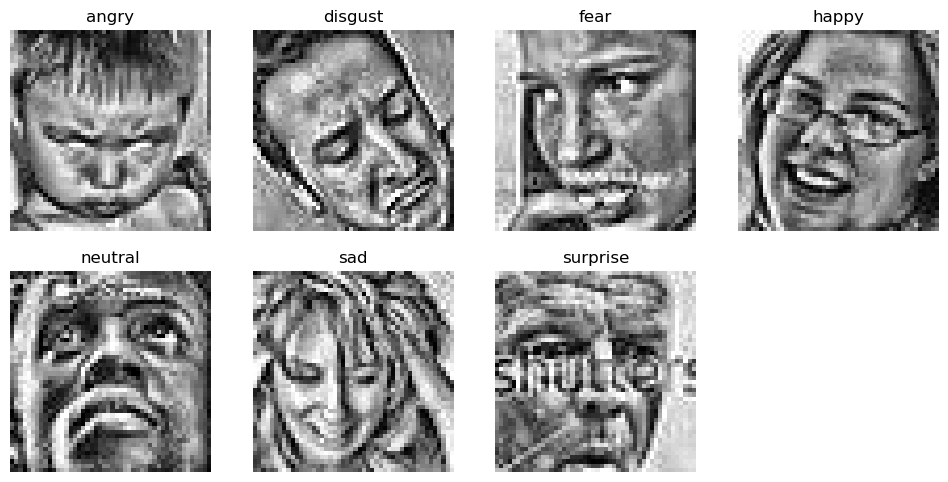

In [34]:
plot_classes(train_path,img_classes)

In [35]:
data_generator = ImageDataGenerator(rescale=1/255)

In [36]:
train_data = data_generator.flow_from_directory(train_path,class_mode='categorical')

Found 28709 images belonging to 7 classes.


In [37]:
test_data= data_generator.flow_from_directory(test_path,class_mode='categorical')

Found 7178 images belonging to 7 classes.


In [44]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(256,256,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
model.fit(train_data,epochs =5, validation_data = test_data)

Epoch 1/5
898/898 ━━━━━━━━━━━━━━━━━━━━ 838s 933ms/step - accuracy: 0.3642 - loss: 1.6643 - val_accuracy: 0.4500 - val_loss: 1.4336
Epoch 2/5
162/898 ━━━━━━━━━━━━━━━━━━━━ 6:05 497ms/step - accuracy: 0.5397 - loss: 1.2163

KeyboardInterrupt: 